In [9]:
import sys
from pathlib import Path

current = Path.cwd()

if (current / "ultrasound_tracker").exists():
    PROJECT_ROOT = current
elif (current.parent / "ultrasound_tracker").exists():
    PROJECT_ROOT = current.parent
else:
    raise FileNotFoundError("Could not find ultrasound_tracker folder")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /Users/grosbedou/PycharmProjects/NDORMS


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from ultrasound_tracker.preprocessing import load_video
from ultrasound_tracker.roi import load_rois, draw_rois, extract_roi
from ultrasound_tracker.aponeurosis_detector import AponeurosisDetector

In [11]:
VIDEO_PATH = PROJECT_ROOT / "data" / "raw" / "UltraTimTrack_test.mp4"
ROI_PATH = PROJECT_ROOT / "data" / "rois" / "UltraTimTrack_test_rois.json"

frames, fps = load_video(str(VIDEO_PATH))
frame0 = frames[0]

rois = load_rois(ROI_PATH)

print("FPS:", fps)
print("Frame shape:", frame0.shape)
print("ROIs:", rois)

Chargé : 2667 frames à 33.3 fps
FPS: 33.341
Frame shape: (562, 706)
ROIs: {'superficial': (15, 21, 690, 42), 'deep': (16, 298, 689, 76), 'fascicle': (17, 65, 686, 226)}


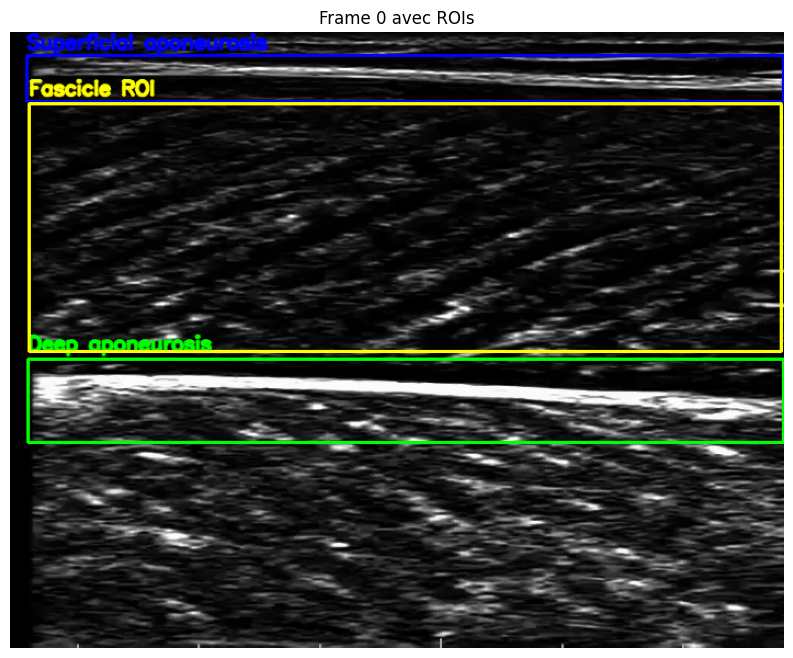

In [12]:
vis = draw_rois(frame0, rois)

plt.figure(figsize=(14, 8))
plt.imshow(vis[..., ::-1])
plt.title("Frame 0 avec ROIs")
plt.axis("off")
plt.show()

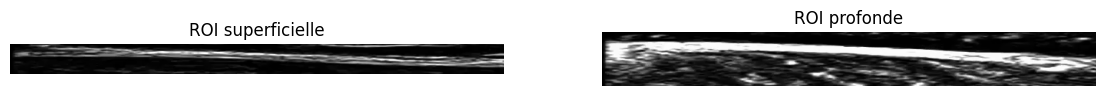

In [13]:
sup_img = extract_roi(frame0, rois["superficial"])
deep_img = extract_roi(frame0, rois["deep"])

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.imshow(sup_img, cmap="gray")
plt.title("ROI superficielle")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(deep_img, cmap="gray")
plt.title("ROI profonde")
plt.axis("off")
plt.show()

In [14]:
apo_detector = AponeurosisDetector(
    method="frangi",
    sigma=10.0,
    th=0.5,
    filtfac=1.0,
    maxlengthratio=0.9,
    frangi_scale_range=(18, 20),
    frangi_scale_ratio=1,
    frangi_black_ridges=False,
    apomargin=20,
    napo=10,
    fillgap=50,
    fit_method="enforce_maxangle",
    maxangle=0.5,
    adaptive_block_size=51,
)

In [15]:
def plot_apo_debug(result, title="Aponeurosis detection"):
    plt.figure(figsize=(18, 10))

    plt.subplot(2, 4, 1)
    plt.imshow(result["image"], cmap="gray")
    plt.title("1. ROI brute")
    plt.axis("off")

    if "frangi_img" in result:
        plt.subplot(2, 4, 2)
        plt.imshow(result["frangi_img"], cmap="gray")
        plt.title("2. Frangi")
        plt.axis("off")

        plt.subplot(2, 4, 3)
        plt.imshow(result["raw_binary"], cmap="gray")
        plt.title("3. Threshold brut")
        plt.axis("off")

        plt.subplot(2, 4, 4)
        plt.imshow(result["combined"], cmap="gray")
        plt.title("4. raw_binary × Frangi")
        plt.axis("off")

        plt.subplot(2, 4, 5)
        plt.imshow(result["gaussian"], cmap="gray")
        plt.title("5. Gaussian")
        plt.axis("off")

        plt.subplot(2, 4, 6)
        plt.imshow(result["gaussian_binary"], cmap="gray")
        plt.title("6. 2e threshold")
        plt.axis("off")

        plt.subplot(2, 4, 7)
        overlay = np.zeros((*result["selected_mask"].shape, 3), dtype=np.float32)
        overlay[..., 1] = result["top2_mask"]
        overlay[..., 0] = result["selected_mask"]
        plt.imshow(overlay)
        plt.title("7. Top2 (vert) + Selected (rouge)")
        plt.axis("off")

    plt.subplot(2, 4, 8)
    plt.imshow(result["image"], cmap="gray")
    plt.title("8. Vecteur + fit")
    plt.axis("off")

    if result["vector_points"] is not None:
        pts = result["vector_points"]
        valid = np.isfinite(pts[:, 1])
        plt.plot(pts[valid, 0], pts[valid, 1], "yo-", linewidth=2, markersize=5)

    if result["line_local"] is not None:
        x1, y1, x2, y2 = result["line_local"]
        plt.plot([x1, x2], [y1, y2], "r-", linewidth=3)

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

Superficial fit coef: [ 0.02471358 14.483997  ]
Superficial line: [  0.        14.483997 689.        31.511656]
Superficial vector y: [nan 15. 19. 21. 22. 25. 27. 27. 29. 30.]


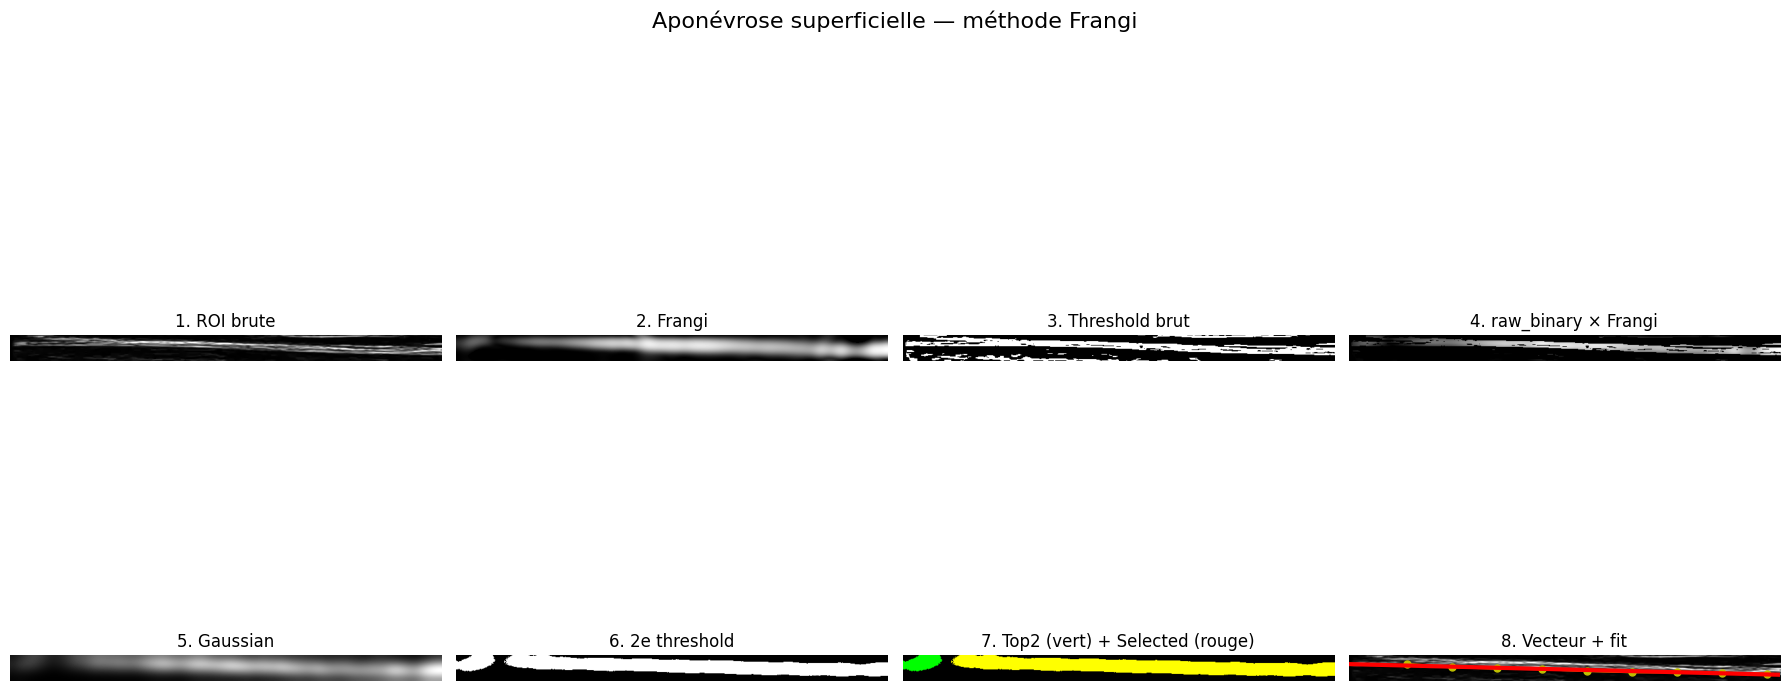

In [16]:
sup_result = apo_detector.detect(sup_img, kind="superficial")

print("Superficial fit coef:", sup_result["fit_coef"])
print("Superficial line:", sup_result["line_local"])
print("Superficial vector y:", sup_result["vector_y"])

plot_apo_debug(sup_result, title="Aponévrose superficielle — méthode Frangi")

Deep fit coef: [ 0.03198653 11.596633  ]
Deep line: [  0.        11.596633 688.        33.603367]
Deep vector y: [18. 16. 15. 16. 18. 21. 24. 29. 32. 37.]


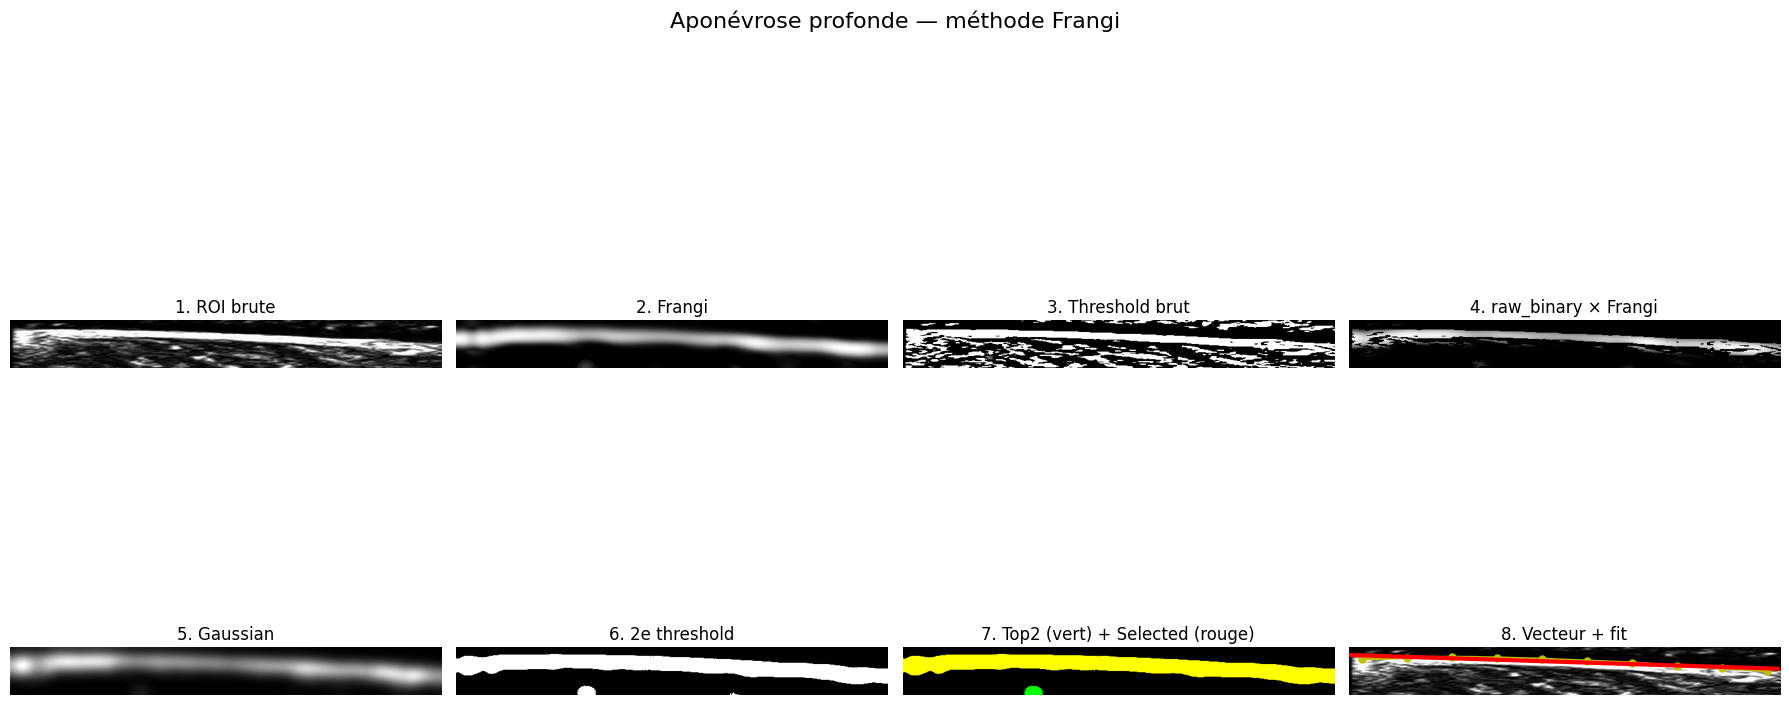

In [17]:
deep_result = apo_detector.detect(deep_img, kind="deep")

print("Deep fit coef:", deep_result["fit_coef"])
print("Deep line:", deep_result["line_local"])
print("Deep vector y:", deep_result["vector_y"])

plot_apo_debug(deep_result, title="Aponévrose profonde — méthode Frangi")

In [18]:
def line_local_to_global(line, roi):
    if line is None:
        return None
    x, y, w, h = roi
    out = line.copy().astype(np.float32)
    out[[0, 2]] += x
    out[[1, 3]] += y
    return out

def points_local_to_global(points, roi):
    if points is None:
        return None
    x, y, w, h = roi
    out = points.copy().astype(np.float32)
    out[:, 0] += x
    out[:, 1] += y
    return out

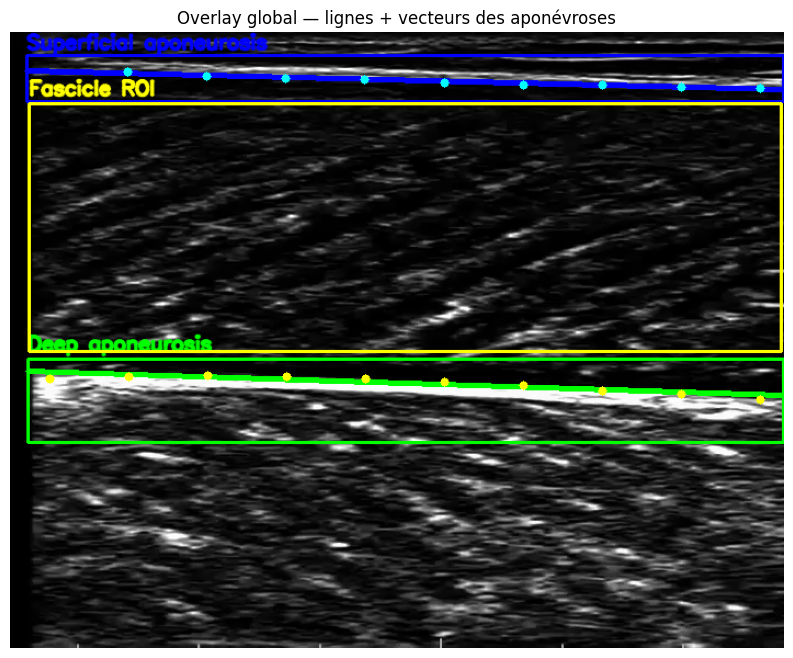

In [19]:
frame_vis = cv2.cvtColor(frame0, cv2.COLOR_GRAY2BGR)

# draw ROIs
frame_vis = draw_rois(frame0, rois)

sup_line_global = line_local_to_global(sup_result["line_local"], rois["superficial"])
deep_line_global = line_local_to_global(deep_result["line_local"], rois["deep"])

sup_pts_global = points_local_to_global(sup_result["vector_points"], rois["superficial"])
deep_pts_global = points_local_to_global(deep_result["vector_points"], rois["deep"])

# superficial line
if sup_line_global is not None:
    x1, y1, x2, y2 = sup_line_global.astype(int)
    cv2.line(frame_vis, (x1, y1), (x2, y2), (255, 0, 0), 3)

# deep line
if deep_line_global is not None:
    x1, y1, x2, y2 = deep_line_global.astype(int)
    cv2.line(frame_vis, (x1, y1), (x2, y2), (0, 255, 0), 3)

# vector points
if sup_pts_global is not None:
    valid = np.isfinite(sup_pts_global[:, 1])
    for px, py in sup_pts_global[valid]:
        cv2.circle(frame_vis, (int(px), int(py)), 4, (255, 255, 0), -1)

if deep_pts_global is not None:
    valid = np.isfinite(deep_pts_global[:, 1])
    for px, py in deep_pts_global[valid]:
        cv2.circle(frame_vis, (int(px), int(py)), 4, (0, 255, 255), -1)

plt.figure(figsize=(14, 8))
plt.imshow(frame_vis[..., ::-1])
plt.title("Overlay global — lignes + vecteurs des aponévroses")
plt.axis("off")
plt.show()

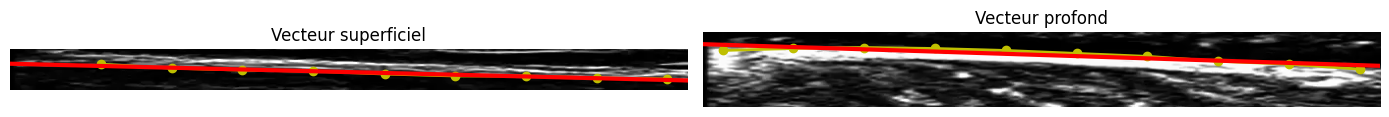

In [20]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.imshow(sup_img, cmap="gray")
plt.title("Vecteur superficiel")
plt.axis("off")
pts = sup_result["vector_points"]
valid = np.isfinite(pts[:, 1])
plt.plot(pts[valid, 0], pts[valid, 1], "yo-", linewidth=2)
if sup_result["line_local"] is not None:
    x1, y1, x2, y2 = sup_result["line_local"]
    plt.plot([x1, x2], [y1, y2], "r-", linewidth=3)

plt.subplot(1, 2, 2)
plt.imshow(deep_img, cmap="gray")
plt.title("Vecteur profond")
plt.axis("off")
pts = deep_result["vector_points"]
valid = np.isfinite(pts[:, 1])
plt.plot(pts[valid, 0], pts[valid, 1], "yo-", linewidth=2)
if deep_result["line_local"] is not None:
    x1, y1, x2, y2 = deep_result["line_local"]
    plt.plot([x1, x2], [y1, y2], "r-", linewidth=3)

plt.tight_layout()
plt.show()